## Import libraries

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Set file paths

In [2]:
RATINGS_PATH = "../data/ratings.csv"
MOVIES_PATH = "../data/movies.csv"
RESULTS_DIR = "../results"

os.makedirs(RESULTS_DIR, exist_ok=True)

print("ratings.csv exists:", os.path.exists(RATINGS_PATH))
print("movies.csv exists:", os.path.exists(MOVIES_PATH))

ratings.csv exists: True
movies.csv exists: True


## Load datasets

In [3]:
ratings = pd.read_csv(RATINGS_PATH)
movies = pd.read_csv(MOVIES_PATH)

print("Ratings dataset loaded successfully.")
print("Movies dataset loaded successfully.")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings dataset loaded successfully.
Movies dataset loaded successfully.
Ratings shape: (20000263, 4)
Movies shape: (27278, 3)


## Show first rows of ratings

In [4]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


## Show first rows of movies

In [5]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Check column names

In [6]:
print("Ratings columns:")
print(ratings.columns.tolist())

print("\nMovies columns:")
print(movies.columns.tolist())

Ratings columns:
['userId', 'movieId', 'rating', 'timestamp']

Movies columns:
['movieId', 'title', 'genres']


## Check missing values

In [7]:
print("Missing values in ratings:")
print(ratings.isnull().sum())

print("\nMissing values in movies:")
print(movies.isnull().sum())

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64


## Basic information about datasets

In [8]:
print("Ratings information:")
print(ratings.info())

print("\nMovies information:")
print(movies.info())

Ratings information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 610.4 MB
None

Movies information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB
None


## Rating distribution

In [9]:
rating_distribution = ratings["rating"].value_counts().sort_index()

print("Rating distribution:")
print(rating_distribution)

Rating distribution:
rating
0.5     239125
1.0     680732
1.5     279252
2.0    1430997
2.5     883398
3.0    4291193
3.5    2200156
4.0    5561926
4.5    1534824
5.0    2898660
Name: count, dtype: int64


## Plot rating distribution

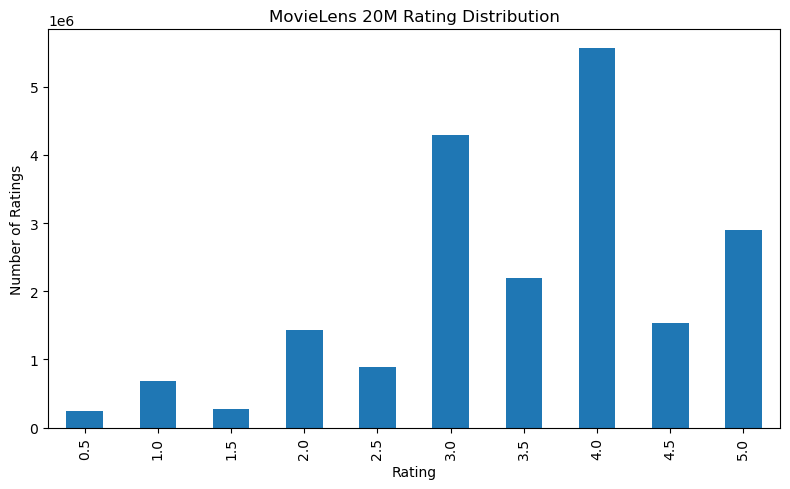

In [10]:
plt.figure(figsize=(8, 5))
rating_distribution.plot(kind="bar")
plt.title("MovieLens 20M Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.savefig("../results/week1_rating_distribution.png")
plt.show()

## Rating statistics

In [11]:
print("Rating statistics:")
print(ratings["rating"].describe())

Rating statistics:
count    2.000026e+07
mean     3.525529e+00
std      1.051989e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


## Count unique users and movies

In [12]:
num_users = ratings["userId"].nunique()
num_movies_rated = ratings["movieId"].nunique()
num_movies_total = movies["movieId"].nunique()

print("Number of unique users:", num_users)
print("Number of unique movies in ratings:", num_movies_rated)
print("Number of movies in movies.csv:", num_movies_total)

Number of unique users: 138493
Number of unique movies in ratings: 26744
Number of movies in movies.csv: 27278


## Analyze ratings per user

In [13]:
ratings_per_user = ratings.groupby("userId")["rating"].count()

print("Ratings per user statistics:")
print(ratings_per_user.describe())

Ratings per user statistics:
count    138493.000000
mean        144.413530
std         230.267257
min          20.000000
25%          35.000000
50%          68.000000
75%         155.000000
max        9254.000000
Name: rating, dtype: float64


## Analyze ratings per movie

In [15]:
ratings_per_movie = ratings.groupby("movieId")["rating"].count()

print("Ratings per movie statistics:")
print(ratings_per_movie.describe())

Ratings per movie statistics:
count    26744.000000
mean       747.841123
std       3085.818268
min          1.000000
25%          3.000000
50%         18.000000
75%        205.000000
max      67310.000000
Name: rating, dtype: float64


## Plot ratings per movie

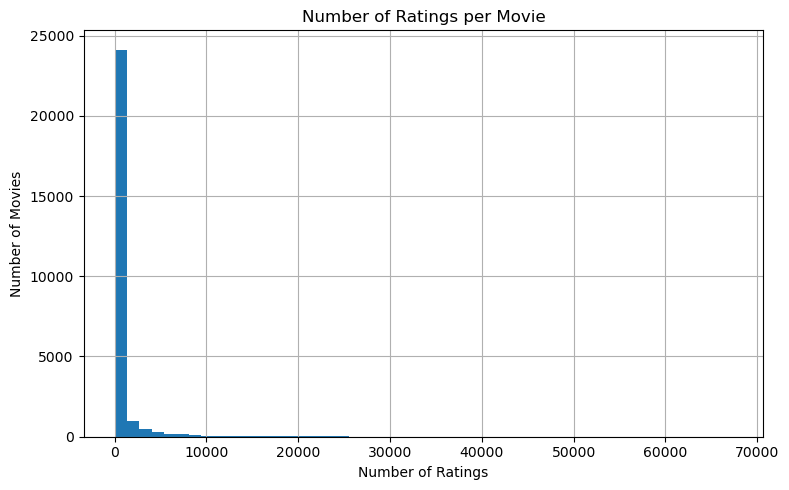

In [16]:
plt.figure(figsize=(8, 5))
ratings_per_movie.hist(bins=50)
plt.title("Number of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.tight_layout()
plt.savefig("../results/week1_ratings_per_movie.png")
plt.show()

## Find top-rated movies

In [17]:
movie_stats = (
    ratings.groupby("movieId")
    .agg(
        average_rating=("rating", "mean"),
        number_of_ratings=("rating", "count")
    )
    .reset_index()
)

movie_stats = movie_stats.merge(movies, on="movieId", how="left")

top_rated_movies = movie_stats[movie_stats["number_of_ratings"] >= 500]

top_rated_movies = top_rated_movies.sort_values(
    by=["average_rating", "number_of_ratings"],
    ascending=False
)

top_rated_movies.head(10)

,movieId,average_rating,number_of_ratings,title,genres
315,318,4.446990,63366,"Shawshank Redemption, The (1994)",Crime|Drama
843,858,4.364732,41355,"Godfather, The (1972)",Crime|Drama
49,50,4.334372,47006,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
523,527,4.310175,50054,Schindler's List (1993),Drama|War
1195,1221,4.275641,27398,"Godfather: Part II, The (1974)",Crime|Drama
1935,2019,4.274180,11611,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama
887,904,4.271334,17449,Rear Window (1954),Mystery|Thriller
7356,7502,4.263182,4305,Band of Brothers (2001),Action|Drama|War
895,912,4.258327,24349,Casablanca (1942),Drama|Romance
905,922,4.256935,6525,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),Drama|Film-Noir|Romance


Find most rated movies

In [18]:
most_rated_movies = movie_stats.sort_values(
    by="number_of_ratings",
    ascending=False
)

most_rated_movies.head(10)

,movieId,average_rating,number_of_ratings,title,genres
293,296,4.174231,67310,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
352,356,4.029000,66172,Forrest Gump (1994),Comedy|Drama|Romance|War
315,318,4.446990,63366,"Shawshank Redemption, The (1994)",Crime|Drama
587,593,4.177057,63299,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
476,480,3.664741,59715,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
257,260,4.190672,54502,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
108,110,4.042534,53769,Braveheart (1995),Action|Drama|War
583,589,3.931954,52244,Terminator 2: Judgment Day (1991),Action|Sci-Fi
2486,2571,4.187186,51334,"Matrix, The (1999)",Action|Sci-Fi|Thriller
523,527,4.310175,50054,Schindler's List (1993),Drama|War


Save top movies table

In [19]:
top_rated_movies.head(20).to_csv(
    "../results/week1_top_rated_movies.csv",
    index=False
)

most_rated_movies.head(20).to_csv(
    "../results/week1_most_rated_movies.csv",
    index=False
)

print("Top movies tables saved.")

Top movies tables saved.


Check movie genres

In [20]:
print("First 10 genre values:")
print(movies["genres"].head(10))

print("\nNumber of unique genre combinations:")
print(movies["genres"].nunique())

First 10 genre values:
0    Adventure|Animation|Children|Comedy|Fantasy
1                     Adventure|Children|Fantasy
2                                 Comedy|Romance
3                           Comedy|Drama|Romance
4                                         Comedy
5                          Action|Crime|Thriller
6                                 Comedy|Romance
7                             Adventure|Children
8                                         Action
9                      Action|Adventure|Thriller
Name: genres, dtype: object

Number of unique genre combinations:
1342


Count individual genres

In [21]:
genre_counts = {}

for genre_list in movies["genres"]:
    genres = str(genre_list).split("|")
    for genre in genres:
        genre_counts[genre] = genre_counts.get(genre, 0) + 1

genre_counts_df = pd.DataFrame(
    list(genre_counts.items()),
    columns=["genre", "count"]
)

genre_counts_df = genre_counts_df.sort_values(by="count", ascending=False)

genre_counts_df

,genre,count
6,Drama,13344
3,Comedy,8374
9,Thriller,4178
5,Romance,4127
7,Action,3520
8,Crime,2939
10,Horror,2611
14,Documentary,2471
0,Adventure,2329
12,Sci-Fi,1743


Plot genre distribution

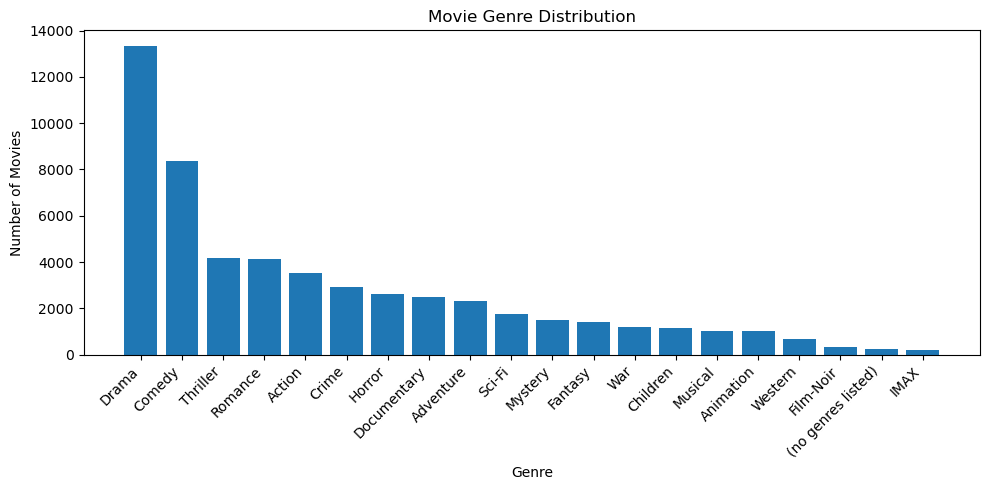

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(genre_counts_df["genre"], genre_counts_df["count"])
plt.title("Movie Genre Distribution")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../results/week1_genre_distribution.png")
plt.show()

Create dataset summary

In [23]:
summary_path = "../results/week1_dataset_summary.txt"

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("MovieLens 20M - Week 1 Dataset Summary\n")
    f.write("=" * 50 + "\n\n")
    
    f.write(f"Ratings shape: {ratings.shape}\n")
    f.write(f"Movies shape: {movies.shape}\n\n")
    
    f.write(f"Number of unique users: {num_users}\n")
    f.write(f"Number of unique movies in ratings: {num_movies_rated}\n")
    f.write(f"Number of movies in movies.csv: {num_movies_total}\n\n")
    
    f.write("Ratings columns:\n")
    for col in ratings.columns:
        f.write(f"- {col}\n")
    
    f.write("\nMovies columns:\n")
    for col in movies.columns:
        f.write(f"- {col}\n")
    
    f.write("\nMissing values in ratings:\n")
    f.write(str(ratings.isnull().sum()))
    
    f.write("\n\nMissing values in movies:\n")
    f.write(str(movies.isnull().sum()))
    
    f.write("\n\nRating distribution:\n")
    f.write(str(rating_distribution))
    
    f.write("\n\nRating statistics:\n")
    f.write(str(ratings["rating"].describe()))
    
    f.write("\n\nRatings per user statistics:\n")
    f.write(str(ratings_per_user.describe()))
    
    f.write("\n\nRatings per movie statistics:\n")
    f.write(str(ratings_per_movie.describe()))

print("Dataset summary saved to:", summary_path)

Dataset summary saved to: ../results/week1_dataset_summary.txt


Final Week 1 output check

In [24]:
print("Week 1 dataset exploration completed successfully.")

print("\nSaved files:")
print("../results/week1_rating_distribution.png")
print("../results/week1_ratings_per_user.png")
print("../results/week1_ratings_per_movie.png")
print("../results/week1_genre_distribution.png")
print("../results/week1_top_rated_movies.csv")
print("../results/week1_most_rated_movies.csv")
print("../results/week1_dataset_summary.txt")

Week 1 dataset exploration completed successfully.

Saved files:
../results/week1_rating_distribution.png
../results/week1_ratings_per_user.png
../results/week1_ratings_per_movie.png
../results/week1_genre_distribution.png
../results/week1_top_rated_movies.csv
../results/week1_most_rated_movies.csv
../results/week1_dataset_summary.txt
